In [104]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec
import typing as t

max_robots = 10
algs = {
    "namo": "NAMO + CR + RepulsiveDR",
    "namo_ndr": "NAMO + CR",
    "namo_ncr": "NAMO",
    "snamo": "S-NAMO + CR + SocialDR",
    "snamo_ndr": "S-NAMO + CR",
    "snamo_ncr": "S-NAMO",
    #"snamo_distance_dr": "S-NAMO + CR + RepulsiveDR",
}

scenario = 'willow_garage_multi_shape'
#scenario = 'willow_garage_multi_shape'
data = pandas.read_csv(f"../report_willow_garage_multi_shape.csv")
data["succeeded"] = data["succeeded"].astype(int)
data_successes = data[data["succeeded"] == 1]
sum_goals_per_agent_per_sim = data.groupby(['n_robots', 'algorithm', 'sim_id', 'agent_id']).sum().reset_index()
max_goals_per_agent_per_sim = sum_goals_per_agent_per_sim.drop(columns='agent_id').groupby(['n_robots', 'algorithm', 'sim_id']).max().reset_index()[['n_robots', 'algorithm', 'n_steps']]
sum_goals_per_agent_per_sim['succeeded'] /= 50
avg_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).mean()
med_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).median()
std_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).std()
count_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).count()

avg_make_span = max_goals_per_agent_per_sim.groupby(['n_robots', 'algorithm']).mean()
count_make_span = max_goals_per_agent_per_sim.groupby(['n_robots', 'algorithm']).count()
std_make_span = max_goals_per_agent_per_sim.groupby(['n_robots', 'algorithm']).std()

data = data.drop(columns=["agent_id", "sim_id"])
success_rates = data.groupby(['n_robots','algorithm'])['succeeded'].mean().reset_index()


In [125]:
avg_make_span

n_steps
n_robots algorithm              
1        namo        3645.950000
         namo_ncr    3645.950000
         namo_ndr    3645.950000
         snamo       3887.850000
         snamo_ncr   3913.950000
         snamo_ndr   3878.850000
2        namo        7264.000000
         namo_ncr    2157.250000
         namo_ndr    4873.750000
         snamo       4888.350000
         snamo_ncr   2423.600000
         snamo_ndr   3771.650000
3        namo        9366.900000
         namo_ncr    1959.000000
         namo_ndr    5536.700000
         snamo       6168.800000
         snamo_ncr   2186.800000
         snamo_ndr   3967.900000
4        namo       12468.000000
         namo_ncr    2271.900000
         namo_ndr    5229.000000
         snamo       7935.800000
         snamo_ncr   1733.650000
         snamo_ndr   4652.650000
5        namo       13574.300000
         namo_ncr    1530.750000
         namo_ndr    5045.050000
         snamo       9159.050000
         snamo_ncr   1606.250000
         snamo_ndr   4535.000000
6        namo       14043.600000
         namo_ncr    1303.000000
         namo_ndr    5254.600000
         snamo      10438.500000
         snamo_ncr   1368.250000
         snamo_ndr   3985.700000
7        namo       14769.100000
         namo_ncr    1598.550000
         namo_ndr    4667.100000
         snamo      11277.800000
         snamo_ncr   1696.800000
         snamo_ndr   4525.200000
8        namo       15239.000000
         namo_ncr    1185.300000
         namo_ndr    4739.600000
         snamo      12571.850000
         snamo_ncr   1363.450000
         snamo_ndr   3572.550000
9        namo       15132.750000
         namo_ncr    1233.700000
         namo_ndr    3676.800000
         snamo      13449.050000
         snamo_ncr   1155.300000
         snamo_ndr   3881.000000
10       namo       14746.736842
         namo_ncr    1082.050000
         namo_ndr    4170.400000
         snamo      13595.500000
         snamo_ncr    818.600000
         snamo_ndr   3188.100000

In [106]:
avg_make_span

n_steps
n_robots algorithm              
1        namo        3645.950000
         namo_ncr    3645.950000
         namo_ndr    3645.950000
         snamo       3887.850000
         snamo_ncr   3913.950000
         snamo_ndr   3878.850000
2        namo        7264.000000
         namo_ncr    2157.250000
         namo_ndr    4873.750000
         snamo       4888.350000
         snamo_ncr   2423.600000
         snamo_ndr   3771.650000
3        namo        9366.900000
         namo_ncr    1959.000000
         namo_ndr    5536.700000
         snamo       6168.800000
         snamo_ncr   2186.800000
         snamo_ndr   3967.900000
4        namo       12468.000000
         namo_ncr    2271.900000
         namo_ndr    5229.000000
         snamo       7935.800000
         snamo_ncr   1733.650000
         snamo_ndr   4652.650000
5        namo       13574.300000
         namo_ncr    1530.750000
         namo_ndr    5045.050000
         snamo       9159.050000
         snamo_ncr   1606.250000
         snamo_ndr   4535.000000
6        namo       14043.600000
         namo_ncr    1303.000000
         namo_ndr    5254.600000
         snamo      10438.500000
         snamo_ncr   1368.250000
         snamo_ndr   3985.700000
7        namo       14769.100000
         namo_ncr    1598.550000
         namo_ndr    4667.100000
         snamo      11277.800000
         snamo_ncr   1696.800000
         snamo_ndr   4525.200000
8        namo       15239.000000
         namo_ncr    1185.300000
         namo_ndr    4739.600000
         snamo      12571.850000
         snamo_ncr   1363.450000
         snamo_ndr   3572.550000
9        namo       15132.750000
         namo_ncr    1233.700000
         namo_ndr    3676.800000
         snamo      13449.050000
         snamo_ncr   1155.300000
         snamo_ndr   3881.000000
10       namo       14746.736842
         namo_ncr    1082.050000
         namo_ndr    4170.400000
         snamo      13595.500000
         snamo_ncr    818.600000
         snamo_ndr   3188.100000

In [107]:
avg_per_agent.loc[[(1, 'namo'),(1, 'snamo'),(5, 'namo'),(5, 'snamo'),(10, 'namo'),(10, 'snamo')]][['succeeded', 'distance_traveled', 'n_transfers', 'replans', 'planning_time']]

succeeded  distance_traveled  n_transfers     replans  \
n_robots algorithm                                                          
1        namo        0.975000       44012.616777    29.650000   49.700000   
         snamo       0.970000       49611.401167    18.850000   48.900000   
5        namo        0.815000      100770.504658    15.430000  209.510000   
         snamo       0.731600       61100.108621     8.310000  156.670000   
10       namo        0.419053       74430.037194     8.194737  349.605263   
         snamo       0.418200       53215.727729     4.670000  283.460000   

                    planning_time  
n_robots algorithm                 
1        namo          201.687598  
         snamo         348.275065  
5        namo          625.463043  
         snamo         784.838548  
10       namo          988.496189  
         snamo        1145.212053

In [108]:
std_per_agent.loc[[(1, 'namo'),(1, 'snamo'),(5, 'namo'),(5, 'snamo'),(10, 'namo'),(10, 'snamo')]][['succeeded', 'distance_traveled', 'n_transfers', 'replans', 'planning_time']]

succeeded  distance_traveled  n_transfers     replans  \
n_robots algorithm                                                          
1        namo        0.028191        8393.433477     5.751659    0.656947   
         snamo       0.032118       10951.327509     2.007224    1.447321   
5        namo        0.107285       35176.865776     4.876774   54.743755   
         snamo       0.145871       19603.846732     3.212020   53.117376   
10       namo        0.141844       29139.223082     3.652784   71.804386   
         snamo       0.168125       26582.292914     2.522482  106.794775   

                    planning_time  
n_robots algorithm                 
1        namo           52.164442  
         snamo          48.131215  
5        namo          144.161261  
         snamo         417.339876  
10       namo          176.958557  
         snamo         544.190374

In [109]:
success_rates

,n_robots,algorithm,succeeded
0,1,namo,0.975000
1,1,namo_ncr,0.975000
2,1,namo_ndr,0.975000
3,1,snamo,0.970000
4,1,snamo_ncr,0.971000
5,1,snamo_ndr,0.970000
6,2,namo,0.936500
7,2,namo_ncr,0.487500
8,2,namo_ndr,0.863000
9,2,snamo,0.892500


In [110]:
def plot_metric_by_num_robots(
    *,
    ax: Axes,
    algs: t.Dict[str, str],
    max_robots: int,
    avg,
    std,
    ylabel: str,
    show_legend: bool = False,
    show_std: bool = False,
    show_std2: bool = False
):
    fig_legend = plt.figure("Legend")

    lines = []
    labels = []
    for alg, title in algs.items():
        means = np.array([avg.loc[(i, alg)] for i in range(1, max_robots + 1)])
        stds = np.array([std.loc[(i, alg)] for i in range(1, max_robots + 1)])
        (line,) = ax.plot(
            range(1, max_robots + 1),
            means,
            label=title,
        )
        lines.append(line)
        labels.append(title)
        if show_std:
            ax.fill_between(
                x=range(1, max_robots + 1),
                y1=means - stds,
                y2=means + stds,
                alpha=0.2,
            )
        #------ JSA
        if show_std2:
            (line_stda,) = ax.plot(
            range(1, max_robots + 1),
            means - stds,
            label=title,
            linestyle = 'dotted',
            color=line.get_color(),
            alpha=0.7,
            linewidth = 0.8,
          )
            (line_stdb,) = ax.plot(
            range(1, max_robots + 1),
            means + stds,
            label=title,
            linestyle = 'dotted',
            color=line.get_color(),
            alpha=0.7,
            linewidth = 0.8,
          )
    fig_legend.legend(lines, labels, loc='center', frameon=False)
    fig_legend.savefig(f'{scenario}_legend.png', bbox_inches='tight')
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])

    #------ JSA
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])
    #ax.grid(color = 'white', linestyle = '--', linewidth = 0.8,axis = 'y')
    #ax.grid(color = 'gray', linestyle = '--', linewidth = 0.8,axis = 'y')
    ax.grid(color = '#DDDFE5', linestyle = '--', linewidth = 1.0,axis = 'y')
    ax.grid(color = '#DDDFE5', linestyle = '--', linewidth = 1.0,axis = 'x')
    #ax.grid(color = '#ACADAF', linestyle = '--', linewidth = 0.8,axis = 'y')
    #ax.grid(color = '#ACADAF', linestyle = '--', linewidth = 0.8,axis = 'x')



    ax.set_facecolor("#F5F8F8")

    ax.spines['bottom'].set_color('#000')
    #ax.spines['top'].set_color('#C6C6D1')
    ax.spines['top'].set_color('white')
    #ax.spines['right'].set_color('#C6C6D1')
    ax.spines['right'].set_color('white')
    ax.spines['left'].set_color('#000')

    ax.tick_params(axis='x', colors='#000',labelsize= 15)
    ax.tick_params(axis='y', colors='#000',labelsize= 15)

    ax.yaxis.label.set_color('#000')
    ax.xaxis.label.set_color('#000')



    # ax.set_facecolor("whitesmoke")
    # ax.set_facecolor("lightgrey")
    # ax.set_facecolor("aliceblue")

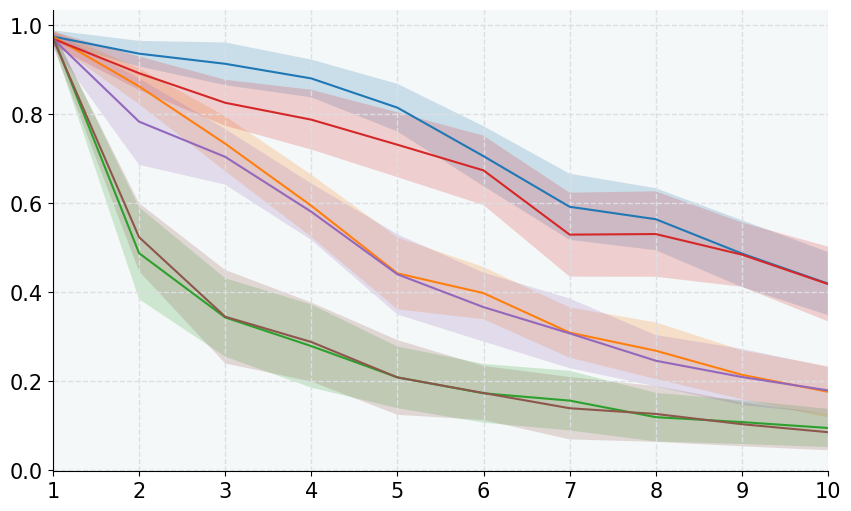

<Figure size 640x480 with 0 Axes>

In [111]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['succeeded'],
    std=std_per_agent['succeeded'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Goal Success Rate",
    show_std=True,
    show_std2=False,
)
fig.savefig(f'{scenario}_success_rates.png', bbox_inches='tight')

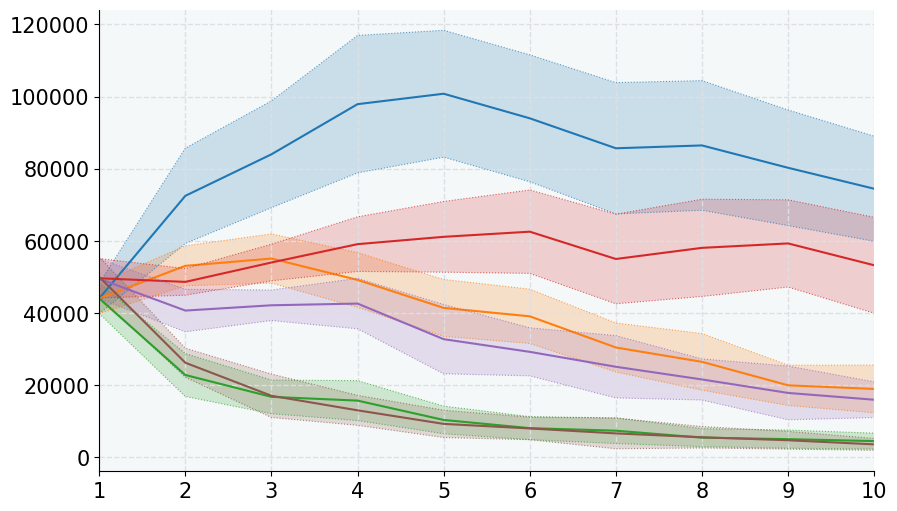

<Figure size 640x480 with 0 Axes>

In [112]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['distance_traveled'],
    std=std_per_agent['distance_traveled'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_distance.png', bbox_inches='tight')

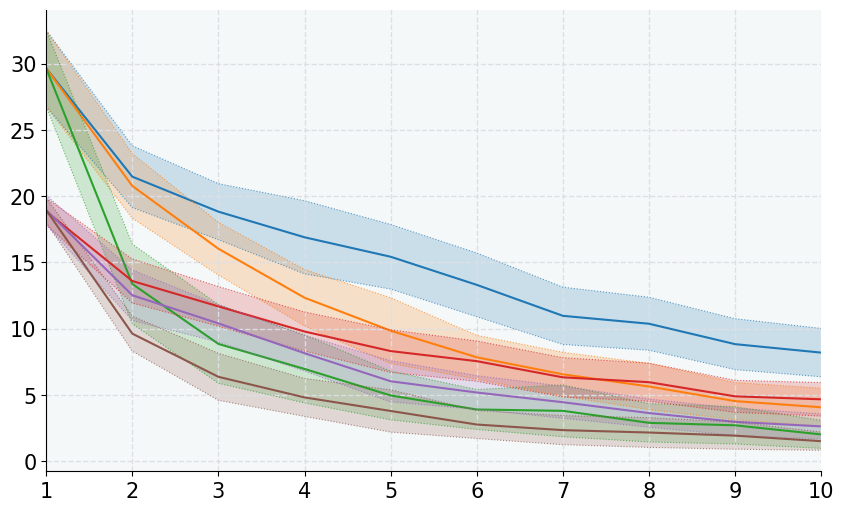

<Figure size 640x480 with 0 Axes>

In [113]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_transfers'],
    std=std_per_agent['n_transfers'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Transfers",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_transfers.png', bbox_inches='tight')

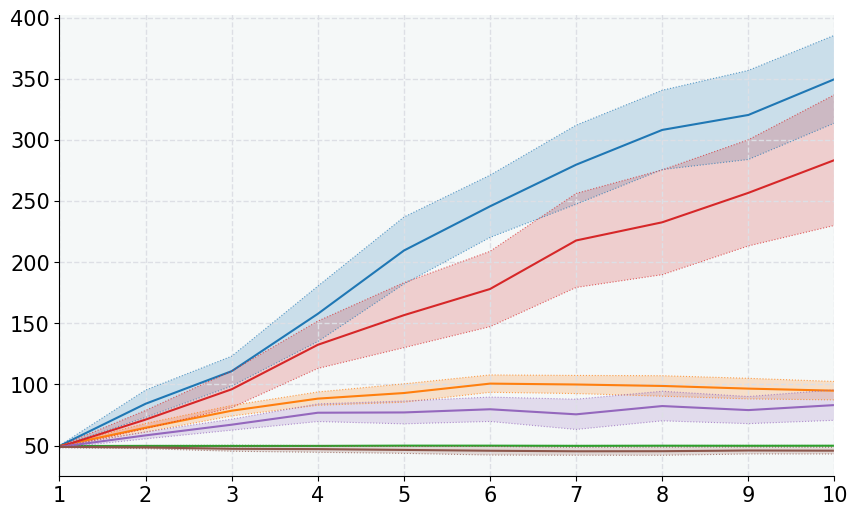

<Figure size 640x480 with 0 Axes>

In [114]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['replans'],
    std=std_per_agent['replans'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Replans",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_replans.png', bbox_inches='tight')

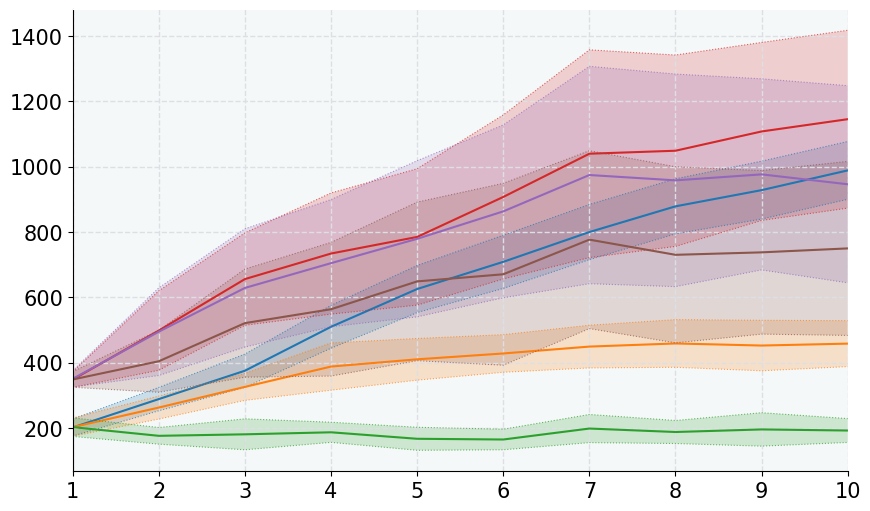

<Figure size 640x480 with 0 Axes>

In [115]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['planning_time'],
    std=std_per_agent['planning_time'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_planning_time.png', bbox_inches='tight')

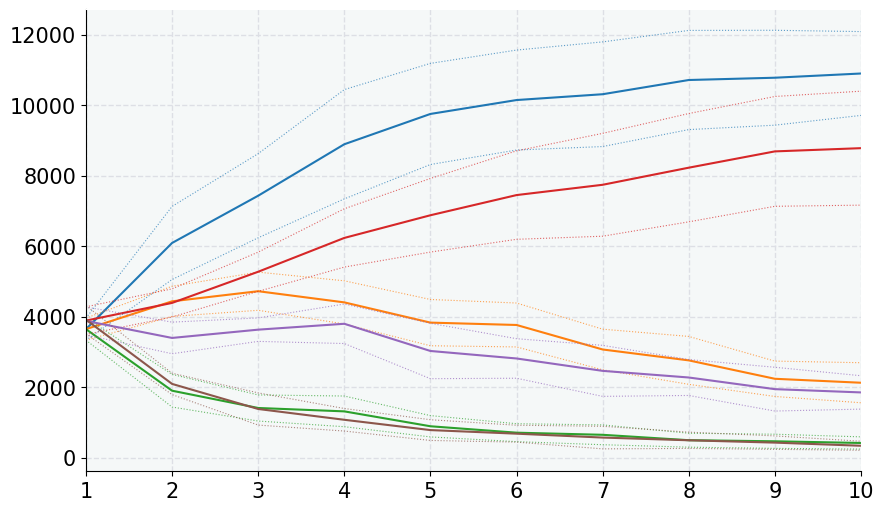

<Figure size 640x480 with 0 Axes>

In [116]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_steps'],
    std=std_per_agent['n_steps'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Steps",
    show_std=False,
     show_std2=True,
)
fig.savefig(f'{scenario}_steps.png', bbox_inches='tight')

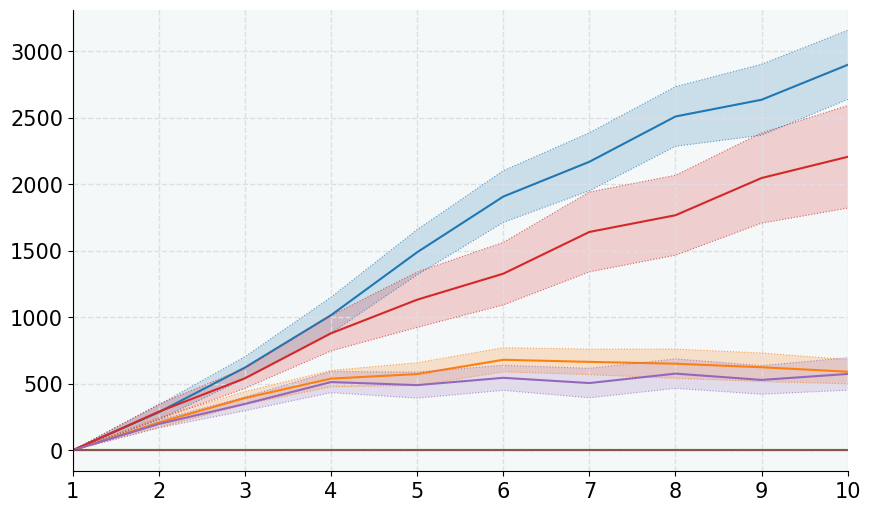

<Figure size 640x480 with 0 Axes>

In [117]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['postponements'],
    std=std_per_agent['postponements'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Postponments",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_postpones.png', bbox_inches='tight')

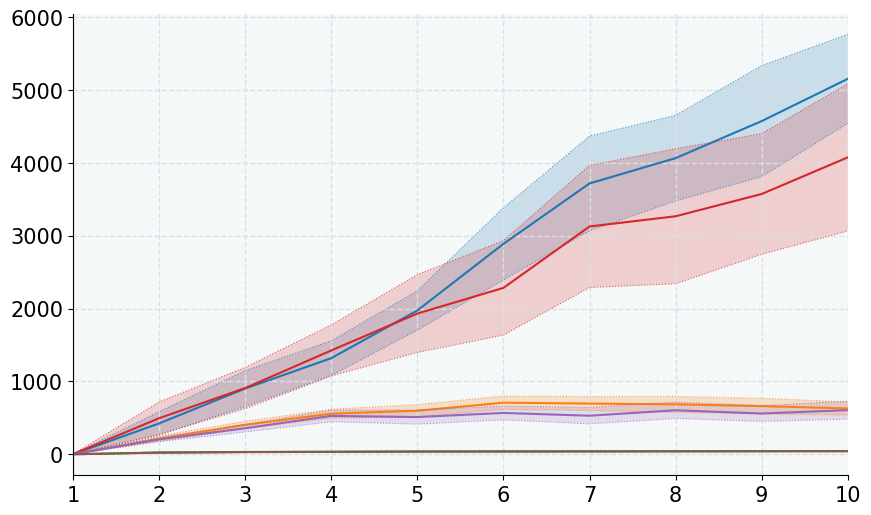

<Figure size 640x480 with 0 Axes>

In [118]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_conflicts'],
    std=std_per_agent['n_conflicts'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Conflicts",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_conflicts.png', bbox_inches='tight')

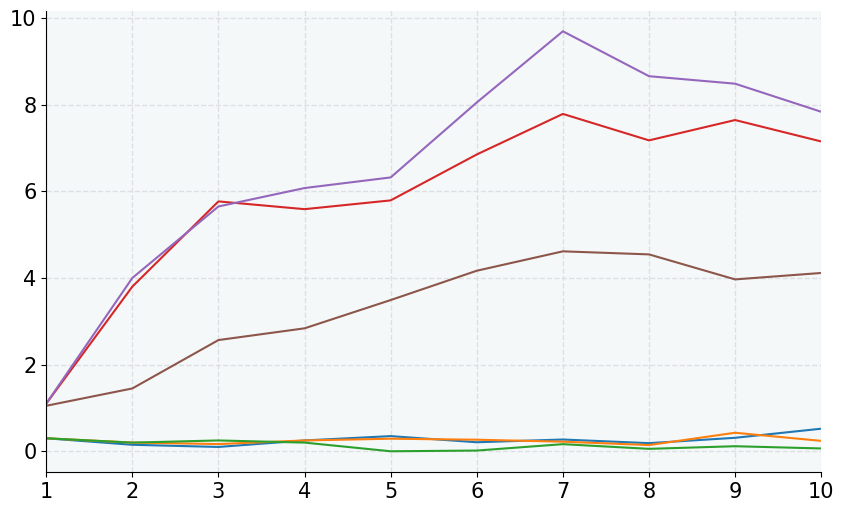

<Figure size 640x480 with 0 Axes>

In [119]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_planning_timeouts'],
    std=std_per_agent['n_planning_timeouts'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Timeouts",
    show_std=False
)
fig.savefig(f'{scenario}_timeouts.png', bbox_inches='tight')

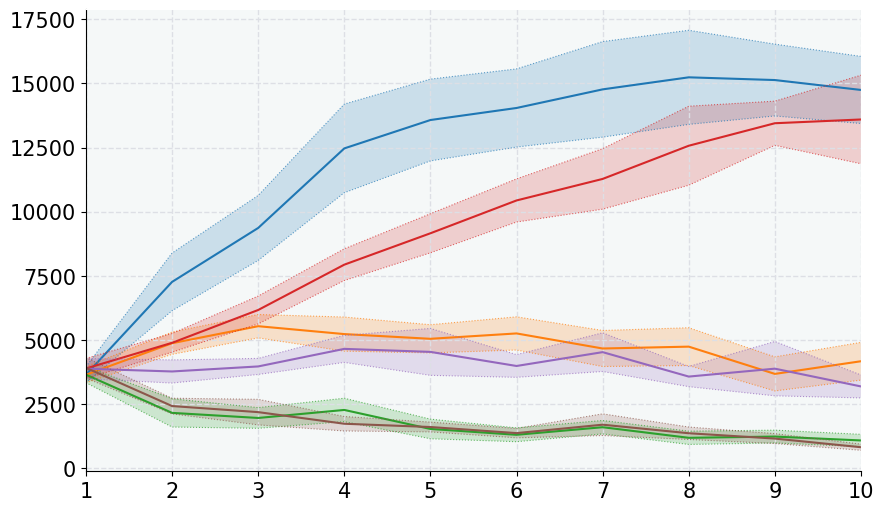

<Figure size 640x480 with 0 Axes>

In [120]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_make_span['n_steps'],
    std=std_make_span['n_steps'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Make-Span",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_make_span.png', bbox_inches='tight')